In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("stock.csv")
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,Industry_Tag,Country,Capital Gains
0,2025-03-20 00:00:00-04:00,386.899994,397.820007,385.799988,389.609985,4003800,0.0,0.0,adobe,ADBE,technology,usa,NaN
1,2025-03-20 00:00:00-04:00,131.100006,132.289993,130.210007,130.509995,378500,0.0,0.0,lvmh,LVMUY,luxury goods,france,NaN
2,2025-03-20 00:00:00-04:00,236.559998,241.759995,236.199997,239.009995,8321600,0.0,0.0,jpmorgan chase & co,JPM,finance,usa,NaN
3,2025-03-20 00:00:00-04:00,60.480000,61.020000,60.340000,60.619999,16503100,0.0,0.0,cisco,CSCO,technology,usa,NaN
4,2025-03-20 00:00:00-04:00,59.020000,59.290001,58.689999,59.230000,2840400,0.0,0.0,unilever,UL,consumer goods,netherlands,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
305209,2000-01-03 00:00:00-05:00,13.822670,13.822670,13.675379,13.720699,48000,0.0,0.0,honda,HMC,automotive,japan,NaN
305210,2000-01-03 00:00:00-05:00,3.990652,4.061914,3.848129,3.990652,134500,0.0,0.0,nintendo,NTDOY,gaming,japan,NaN
305211,2000-01-03 00:00:00-05:00,31.512873,31.512873,30.431443,30.799129,6057400,0.0,0.0,costco,COST,retail,usa,NaN
305212,2000-01-03 00:00:00-05:00,38.147537,38.255972,35.935457,37.496925,53076000,0.0,0.0,cisco,CSCO,technology,usa,NaN


In [4]:
df['Date'] = pd.to_datetime(df['Date'],utc = True)
df['Year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month

In [5]:
aapl_df = df[(df['Ticker'] == 'AAPL') & (df['Year'] >= 2020) & (df['Year'] <=  2025)].sort_values('Date')
aapl_df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,Industry_Tag,Country,Capital Gains,Year,month
81652,2020-01-02 05:00:00+00:00,72.246685,73.310001,71.990615,73.249031,135480400,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1
81624,2020-01-03 05:00:00+00:00,72.468602,73.305105,72.310083,72.536888,146322800,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1
81564,2020-01-06 05:00:00+00:00,71.649176,73.153905,71.395540,73.114883,118387200,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1
81486,2020-01-07 05:00:00+00:00,73.124639,73.383150,72.549088,72.771019,108872000,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1
81431,2020-01-08 05:00:00+00:00,72.471053,74.246491,72.471053,73.941643,132079200,0.0,0.0,apple,AAPL,technology,usa,NaN,2020,1


In [6]:
import plotly.express as px

In [7]:
#Filter the data
ticker = 'AAPL'
aapl_df = df[df['Ticker'] == ticker]

In [18]:
aapl_df = aapl_df.copy()  # Avoid SettingWithCopyWarning

aapl_df['Daily_Return'] = aapl_df['Close'].pct_change()

In [19]:
aapl_df['Daily_Return'] = aapl_df['Close'].pct_change() * 100

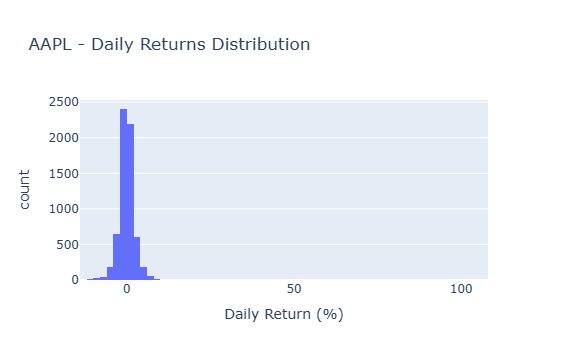

In [20]:
#Plot the data
fig = px.histogram(aapl_df,
                x='Daily_Return',
                nbins=100,
                title='AAPL - Daily Returns Distribution',
                labels={'Daily_Return': 'Daily Return (%)'})
fig.show()

In [21]:
#Filter the data
ticker = 'AAPL'
aapl_df = df[df['Ticker'] == ticker]

In [24]:
aapl_df['Daily_Return'] = aapl_df['Close'].pct_change()

aapl_df['Cumulative_Return'] = (1 + aapl_df['Daily_Return']).cumprod() - 1

C:\Users\Sameer kampa\AppData\Local\Temp\ipykernel_12064\945233849.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Sameer kampa\AppData\Local\Temp\ipykernel_12064\945233849.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [25]:
aapl_df['Daily_Return'] = aapl_df['Close'].pct_change() * 100

aapl_df['Cumulative_Return'] = (1 + aapl_df['Daily_Return'] / 100).cumprod() - 1

C:\Users\Sameer kampa\AppData\Local\Temp\ipykernel_12064\1341998991.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Sameer kampa\AppData\Local\Temp\ipykernel_12064\1341998991.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

